In [1]:
import numpy as np 
import pandas as pd 

In [4]:
df = pd.read_csv('test_processed.csv')
df.sample(5)

,ohe__Make_alfa romeo,ohe__Make_aston martin,ohe__Make_audi,ohe__Make_bentley,ohe__Make_bmw,ohe__Make_bugatti,ohe__Make_buick,ohe__Make_cadillac,ohe__Make_chevrolet,ohe__Make_chrysler,...,ohe__Transmission_M6,ohe__Transmission_M7,oe__Fuel Type,scale__Engine Size(L),scale__Cylinders,scale__Fuel Consumption City (L/100 km),scale__Fuel Consumption Hwy (L/100 km),scale__Fuel Consumption Comb (L/100 km),scale__Fuel Consumption Comb (mpg),CO2 Emissions(g/km)
180,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,-0.569406,-0.887062,-0.522360,-0.567573,-0.527132,0.372846,222
204,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,0.237631,0.195255,0.575043,0.925477,0.694855,-0.738705,308
393,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,2.512010,3.442209,2.066386,1.540263,1.916842,-1.433424,390
1012,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,1.0,1.851707,1.277573,1.785001,2.111135,1.916842,-1.433424,384
820,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,3.0,-0.129204,0.195255,-0.156559,-0.435834,-0.255579,-0.043985,237


In [6]:
import joblib 
model = joblib.load('model.joblib', 'r')

/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DummyRegressor from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator DecisionTreeRegressor from version 1.9.0 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator GradientBoostingRegressor from version 1.9.0 when using version 1.6.1. This might lead to

In [18]:
x_test = df.drop(columns=['CO2 Emissions(g/km)'])
y_test = df['CO2 Emissions(g/km)']

In [19]:
y_pred = model.predict(x_test)

In [20]:
y_pred 

array([290.92416591, 263.65379564, 280.16974889, ..., 171.02045711,
       259.99742279, 280.66819416])

In [21]:
y_test

,CO2 Emissions(g/km)
0,293
1,262
2,282
3,271
4,274
...,...
1194,268
1195,273
1196,168
1197,263


In [23]:
from sklearn.metrics import r2_score, root_mean_squared_error, mean_absolute_error

rmse = root_mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

In [33]:
import matplotlib.pyplot as plt 

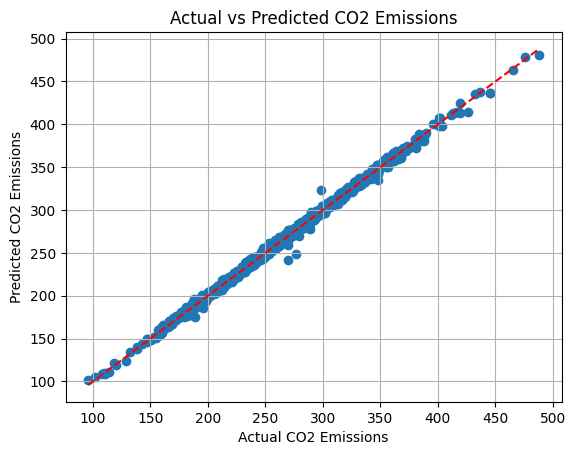

In [53]:
plt.scatter(y_test, y_pred)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], color='red', linestyle='--')

plt.xlabel("Actual CO2 Emissions")
plt.ylabel("Predicted CO2 Emissions")
plt.title("Actual vs Predicted CO2 Emissions")
plt.grid(True)

plt.savefig('img.png')